(ch:model-selection)=
# 2. Model selection and the bootstrap

```{admonition} Goals of this chapter
:class: note
After working through this chapter you should be able to

* decide when to stop adding parameters to a (nested) model, using the residuals, $\chi^2$ per degree of freedom, and the AIC and BIC;
* explain the difference between the AIC and the BIC and which one to use for which goal;
* obtain a confidence interval for a parameter with the non-parametric bootstrap, and explain when it beats the least-squares covariance.

This chapter accompanies the first parts of Lectures 2 and 3. Both topics are "frequentist" tools, but they are in daily use, they are in the assignment, and the bootstrap is closer to the Bayesian sampling methods of Chapter {ref}`6 <ch:mcmc>` than it may seem.
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit, OptimizeWarning
import warnings
warnings.simplefilter("ignore", OptimizeWarning)   # high-order polynomial fits complain about their covariance; we only use the best fit

rng = np.random.default_rng(10)
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True

def chi2_stat(model_y, y, sigma_y):
    return np.sum((model_y - y)**2 / sigma_y**2)

## 2.1 Adding parameters to a model

A recurring situation: you have fitted a model, the fit is not perfect, and you wonder whether adding a parameter is justified. Say you fitted a line and consider a parabola,

$$
y = a + b x \quad\longrightarrow\quad y = a + b x + c x^2 .
$$

The line is a special case ($c=0$) of the parabola. We call the smaller model **nested** in the larger one: model B is nested in model A if B contains a subset of the parameters of A (with the others fixed). Comparing non-nested models (say, a power law versus an exponential) is possible too, but requires more care with the normalization of the likelihoods; in this course we restrict ourselves to nested models.

Use common sense first:

* **Look at the residuals.** Systematic "features" in $y_i - m(x_i,\hat\theta)$ (a bump, a trend, a curvature) indicate that the smaller model misses a real effect.
* **Look at the size of the residuals** compared to the uncertainties. For Gaussian uncertainties, 32% of the points should deviate by more than $1\sigma$ and 5% by more than $2\sigma$. If far fewer points do, your uncertainties are too large; if far more do, they are too small or the model is missing something.
* **Do you have a good (physical) reason to expect the more complex model?**

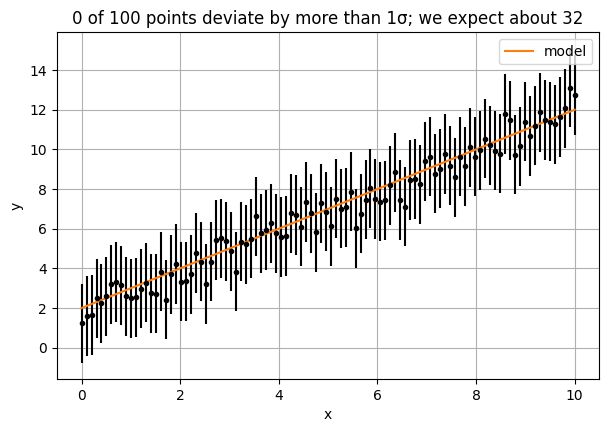

In [2]:
# The lecture-3 puzzle: what is wrong with these data?
x = np.linspace(0, 10, 100)
y_true = 2 + x
sigma_reported = np.full_like(x, 2.0)          # the uncertainty in the catalogue
y_obs = rng.normal(y_true, 0.7)                # ... but the real scatter is much smaller

n_out = np.sum(np.abs(y_obs - y_true) > sigma_reported)
fig, ax = plt.subplots()
ax.errorbar(x, y_obs, sigma_reported, fmt="ok", ms=3)
ax.plot(x, y_true, color="C1", label="model")
ax.set_title(f"{n_out} of 100 points deviate by more than 1σ; we expect about 32")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend();

### $\chi^2$ never increases, $\chi^2$ per degree of freedom might

Two quiz questions from the lecture. *Adding a parameter to a nested model will never increase the best-fit $\chi^2$.* True: the larger model contains the smaller one, so the best fit of the larger model is at least as good. *Adding a parameter will never increase $\chi^2/\mathrm{dof}$.* False: the dof decreases by one for every parameter, so if the improvement in $\chi^2$ is less than about one, $\chi^2/\mathrm{dof}$ goes up. So $\chi^2/\mathrm{dof}$ already contains a crude "penalty" for extra parameters. The information criteria below make this penalty explicit and principled.

## 2.2 Information criteria: AIC and BIC

Both criteria combine the maximum of the likelihood, $\hat{\mathcal L} = \mathcal{L}(\hat\theta)$, with a penalty for the number of free parameters $k$:

$$
\mathrm{AIC} = -2\ln\hat{\mathcal L} + 2k ,
$$ (eq:aic)

$$
\mathrm{BIC} = -2\ln\hat{\mathcal L} + k\ln N ,
$$ (eq:bic)

with $N$ the number of data points. In both cases **lower is better**: adding a parameter is justified only if the improvement of $-2\ln\hat{\mathcal L}$ is larger than the penalty. For Gaussian uncertainties $-2\ln\hat{\mathcal L} = \chi^2_{\min} + \mathrm{const}$ (Eq. {eq}`eq:loglike-chi2` of Chapter 1), so for nested models with the same data the constant cancels and you can simply use $\chi^2_{\min}$ in place of $-2\ln\hat{\mathcal L}$.

Since $\ln N > 2$ for $N > 7$, the BIC penalizes extra parameters more strongly than the AIC for any realistic dataset, and the penalty grows with the size of the dataset.

**Interpreting differences.** Only differences between models matter. A rule of thumb for the AIC: the quantity $\exp[(\mathrm{AIC}_{\min} - \mathrm{AIC}_i)/2]$ is the *relative likelihood* of model $i$ compared to the best model. With $\mathrm{AIC}_1 = 101$, $\mathrm{AIC}_2 = 104$ and $\mathrm{AIC}_3 = 111$, model 2 is $e^{-1.5} \approx 0.22$ times and model 3 $e^{-5} \approx 0.007$ times as probable as model 1 to minimize the information loss; model 3 can be dropped. For the BIC a difference of 2–6 is "positive" and $>10$ "very strong" evidence for the lower-BIC model (Kass & Raftery 1995).

**AIC versus BIC.** The two criteria answer different questions. The AIC (Akaike) estimates how well the model will *predict new data*; it does not assume that the true model is among the candidates. The BIC (Schwarz) approximates the Bayesian posterior probability of the model, and selects the *simplest model that explains the data* if the true model is in the set. Hence: use the AIC if your goal is prediction, the BIC if your goal is to find the simplest adequate description. Statisticians disagree about how seriously to take the "Bayesian" in BIC: Wasserman calls choosing the model with the lowest BIC "like choosing the model with highest posterior probability", while Gelman et al. write "BIC, a misleading name, we believe... We do not typically find it useful to think about the posterior probabilities of models."

```{admonition} The information criteria tell you nothing about absolute quality
:class: warning
The AIC and BIC compare models *relative to each other*. A model with the lowest AIC can still be a terrible fit. Always check $\chi^2/\mathrm{dof}$ and the residuals as well.
```

### Worked example: how many polynomial terms?

We simulate data from a cubic polynomial whose two highest-order terms are small, so that the data deviate from a straight line by at most a few $\sigma$. We then fit polynomials of increasing degree and watch $\chi^2$, $\chi^2/\mathrm{dof}$, the AIC and the BIC. (This is Part 3 of the "multiverse" werkcollege notebook.)

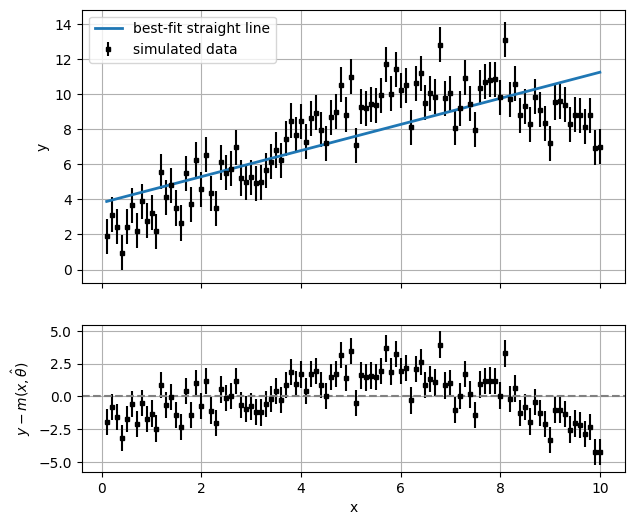

In [3]:
def poly_model(x, *p):
    """polynomial with len(p) free parameters (highest order first, as in np.polyval)"""
    return np.polyval(p, x)

a_true, b_true = 2.0, 1.0
p_true = [-0.03, 0.25, b_true, a_true]      # a modest deviation from the straight line a + b x
n_points = 100
x_data = np.linspace(0.1, 10, n_points)

def sim_data(x, sigma=1.0):
    y_unc = np.full_like(x, sigma)
    return rng.normal(poly_model(x, *p_true), y_unc), y_unc

y_sim, y_unc = sim_data(x_data)

# fit a straight line and show the residuals
popt2, _ = curve_fit(poly_model, x_data, y_sim, sigma=y_unc, p0=np.zeros(2))
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(7, 6), height_ratios=[0.65, 0.35])
axs[0].errorbar(x_data, y_sim, y_unc, fmt="sk", ms=3, label="simulated data")
axs[0].plot(x_data, poly_model(x_data, *popt2), lw=2, label="best-fit straight line")
axs[0].set_ylabel("y"); axs[0].legend()
axs[1].errorbar(x_data, y_sim - poly_model(x_data, *popt2), y_unc, fmt="sk", ms=3)
axs[1].axhline(0, ls="--", color="gray")
axs[1].set_ylabel(r"$y - m(x,\hat\theta)$"); axs[1].set_xlabel("x");

The residuals of the straight-line fit show a clear systematic pattern (negative at both ends, positive in the middle), so we are motivated to add parameters.

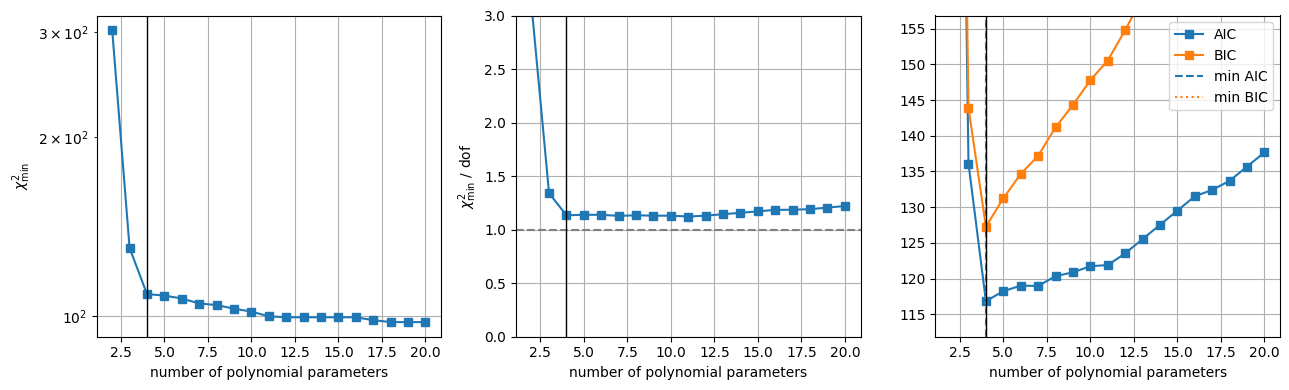

In [4]:
def AIC(log_like_max, k):
    return -2 * log_like_max + 2 * k

def BIC(log_like_max, k, n):
    return -2 * log_like_max + np.log(n) * k

n_par_arr = np.arange(2, 21)
chi2_arr, aic_arr, bic_arr = (np.zeros(len(n_par_arr)) for _ in range(3))

p0 = np.zeros(2)
for i, k in enumerate(n_par_arr):
    popt, _ = curve_fit(poly_model, x_data, y_sim, sigma=y_unc, p0=p0)
    p0 = [0.0] + list(popt)                    # start the next fit at the current best fit (with one extra parameter)
    chi2_arr[i] = chi2_stat(poly_model(x_data, *popt), y_sim, y_unc)
    log_like = -0.5 * chi2_arr[i]              # + a constant that is the same for all models
    aic_arr[i] = AIC(log_like, k)
    bic_arr[i] = BIC(log_like, k, n_points)

fig, axs = plt.subplots(1, 3, figsize=(13, 4))
axs[0].plot(n_par_arr, chi2_arr, "-s"); axs[0].set_yscale("log"); axs[0].set_ylabel(r"$\chi^2_{\min}$")
axs[1].plot(n_par_arr, chi2_arr / (n_points - n_par_arr), "-s"); axs[1].axhline(1, ls="--", color="gray")
axs[1].set_ylabel(r"$\chi^2_{\min}$ / dof"); axs[1].set_ylim(0, 3)
axs[2].plot(n_par_arr, aic_arr, "-s", label="AIC"); axs[2].plot(n_par_arr, bic_arr, "-s", label="BIC")
axs[2].axvline(n_par_arr[np.argmin(aic_arr)], ls="--", color="C0", label="min AIC")
axs[2].axvline(n_par_arr[np.argmin(bic_arr)], ls=":", color="C1", label="min BIC")
axs[2].set_ylim(np.min(aic_arr) - 5, np.min(aic_arr) + 40); axs[2].legend()
for ax in axs:
    ax.axvline(len(p_true), color="k", lw=1); ax.set_xlabel("number of polynomial parameters")
plt.tight_layout()

The black line marks the true number of parameters (4). $\chi^2$ drops steeply until 4 parameters and then keeps decreasing slowly (it never increases), $\chi^2/\mathrm{dof}$ reaches $\approx 1$ at 4 parameters, and both information criteria have their minimum at or near 4. Beyond that, every extra parameter costs more than it gains.

A single dataset can be lucky. To see how reliable the criteria are we repeat the experiment on 300 simulated datasets and record the number of parameters preferred by each criterion.

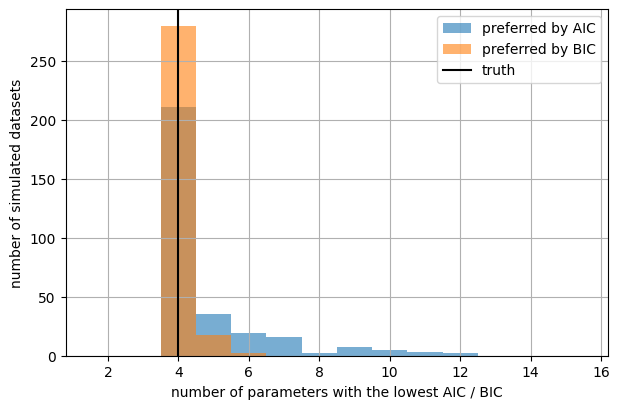

In [5]:
n_sim = 300
n_par_arr = np.arange(2, 16)
aic_best, bic_best = np.zeros(n_sim, dtype=int), np.zeros(n_sim, dtype=int)

for j in range(n_sim):
    y_sim_j, y_unc_j = sim_data(x_data)
    aic_j, bic_j = np.zeros(len(n_par_arr)), np.zeros(len(n_par_arr))
    p0 = np.zeros(2)
    for i, k in enumerate(n_par_arr):
        popt, _ = curve_fit(poly_model, x_data, y_sim_j, sigma=y_unc_j, p0=p0)
        p0 = [0.0] + list(popt)
        log_like = -0.5 * chi2_stat(poly_model(x_data, *popt), y_sim_j, y_unc_j)
        aic_j[i], bic_j[i] = AIC(log_like, k), BIC(log_like, k, n_points)
    aic_best[j] = n_par_arr[np.argmin(aic_j)]
    bic_best[j] = n_par_arr[np.argmin(bic_j)]

bins = np.arange(1.5, 16, 1)
fig, ax = plt.subplots()
ax.hist(aic_best, bins=bins, alpha=0.6, label="preferred by AIC")
ax.hist(bic_best, bins=bins, alpha=0.6, label="preferred by BIC")
ax.axvline(len(p_true), color="k", label="truth")
ax.set_xlabel("number of parameters with the lowest AIC / BIC"); ax.set_ylabel("number of simulated datasets"); ax.legend();

The BIC almost always picks the true number of parameters; the AIC picks the true model most of the time, but has a tail towards more complex models (it is willing to pay for a small gain in predictive power). This is the general pattern: the BIC is *consistent* (it finds the true model if it is in the set, for $N\to\infty$), the AIC is not, but the AIC is better at prediction when all candidate models are approximations.

## 2.3 The bootstrap

### The idea

In Chapter 1 we saw that the confidence interval of a least-squares fit is only reliable when the uncertainties are Gaussian, known, and the model is linear (or $N$ is large). What if we cannot trust these assumptions? If we could repeat the experiment many times we would simply look at the distribution of the best-fit values; that distribution *is* the confidence interval we want. We cannot get more data, but we can do the next best thing.

The **non-parametric bootstrap** (Efron 1979): from the original dataset of size $N$, draw a new dataset of size $N$ *with replacement* (so some points appear twice, others not at all). This *bootstrap sample* is a plausible alternative outcome of the experiment. Fit it, record the best-fit parameters, and repeat $B$ times. The distribution of the $B$ best-fit values approximates the distribution of the estimator, and hence the confidence interval. The name refers to the English idiom of pulling oneself up by one's own bootstraps (Baron Münchhausen, in the original tale, used his own hair to pull himself and his horse out of a swamp); it feels circular, but it works remarkably well, and it needs almost no assumptions other than that the sample is representative of the population.

The **parametric bootstrap** instead draws new datasets from the fitted model (i.e. it simulates data from the generative model with $\theta=\hat\theta$). This is close to what we did in the "multiverse" of Chapter 1, except that there we could cheat and simulate from the *true* parameters. The parametric bootstrap fails if the model is misspecified, whereas the non-parametric bootstrap does not care.

```{admonition} The bootstrap recipe
:class: note
1. For $j = 1, \dots, B$: draw $N$ indices with replacement, `idx = rng.integers(0, N, size=N)`, and fit the model to `(x[idx], y[idx], sigma_y[idx])`. Store the best fit $\hat\theta^{(j)}$.
2. The $\gamma$ confidence interval of a parameter is given by the quantiles of the bootstrap distribution:
   $(\hat\theta_{\rm l}, \hat\theta_{\rm u}) = (q_{(1-\gamma)/2},\, q_{(1+\gamma)/2})$, i.e. for $\gamma = 0.683$ the 15.9% and 84.1% percentiles.
3. $B = 500$ is fine for a quick look; use $B \sim 10^4$ for publication-quality intervals (the tails of the distribution are the slowest to converge).

Do **not** summarize the bootstrap distribution by its mean and standard deviation: its whole point is that it can be asymmetric and non-Gaussian.
```

When should you bootstrap? When you cannot compute the confidence interval from least squares because you are not sure the uncertainties are Gaussian, because the model is non-linear (asymmetric intervals), because you have no uncertainties at all, or because you do not want to do Bayesian statistics.

### Worked example 1: the bootstrap agrees with least squares for a linear model

First a sanity check in a case where we know the right answer. We simulate 100 points from a straight line with known Gaussian uncertainties, so the `absolute_sigma=True` covariance of `curve_fit` is exact.

least squares: b = 1.019 +/- 0.035
bootstrap    : b = 1.020 -0.032 +0.030


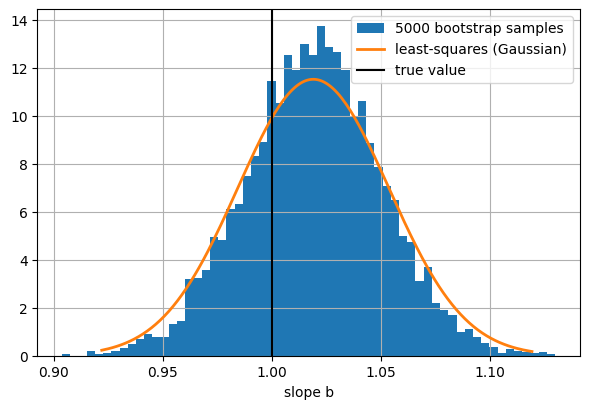

In [6]:
def line(x, a, b):
    return a + b * x

n_points = 100
x_data = np.linspace(0.1, 10, n_points)
y_sim, y_unc = rng.normal(line(x_data, a_true, b_true), 1.0), np.ones(n_points)

def bootstrap_fit(model, x, y, sigma_y, p0, B=5000):
    """non-parametric bootstrap: returns an array of shape (B, n_parameters) with the best-fit values"""
    n = len(x)
    theta_b = np.zeros((B, len(p0)))
    for b in range(B):
        idx = rng.integers(0, n, size=n)                 # draw with replacement
        theta_b[b], _ = curve_fit(model, x[idx], y[idx], sigma=sigma_y[idx], p0=p0)
    return theta_b

popt, pcov = curve_fit(line, x_data, y_sim, sigma=y_unc, absolute_sigma=True)
theta_boot = bootstrap_fit(line, x_data, y_sim, y_unc, p0=popt)

lo, med, hi = np.percentile(theta_boot[:, 1], [15.9, 50, 84.1])
print(f"least squares: b = {popt[1]:.3f} +/- {np.sqrt(pcov[1,1]):.3f}")
print(f"bootstrap    : b = {med:.3f} -{med-lo:.3f} +{hi-med:.3f}")

fig, ax = plt.subplots()
ax.hist(theta_boot[:, 1], bins=60, density=True, label=f"{len(theta_boot)} bootstrap samples")
bb = np.linspace(*np.percentile(theta_boot[:, 1], [0.1, 99.9]), 200)
ax.plot(bb, stats.norm.pdf(bb, popt[1], np.sqrt(pcov[1, 1])), lw=2, label="least-squares (Gaussian)")
ax.axvline(b_true, color="k", label="true value")
ax.set_xlabel("slope b"); ax.legend();

Good agreement. Now the same on real data: the slope of the Hogg et al. line of Chapter 1 has a least-squares uncertainty of 0.108.

In [7]:
hogg = np.genfromtxt("data/hogg_table1.csv", delimiter=",", names=True)
clean = hogg["id"] >= 5
x_h, y_h, sy_h = hogg["x"][clean], hogg["y"][clean], hogg["sigma_y"][clean]

popt_h, pcov_h = curve_fit(line, x_h, y_h, sigma=sy_h, absolute_sigma=True)
theta_boot_h = bootstrap_fit(line, x_h, y_h, sy_h, p0=popt_h, B=5000)
lo, med, hi = np.percentile(theta_boot_h[:, 1], [15.9, 50, 84.1])
print(f"least squares: slope = {popt_h[1]:.3f} +/- {np.sqrt(pcov_h[1,1]):.3f}")
print(f"bootstrap    : slope = {med:.3f} -{med-lo:.3f} +{hi-med:.3f}   (16 points only)")

least squares: slope = 2.240 +/- 0.108
bootstrap    : slope = 2.241 -0.093 +0.166   (16 points only)


With only 16 points the two methods are close but not identical; the bootstrap does not use the $\sigma_{y,i}$ to set the width of the distribution (only as fit weights), so it also provides an independent check that the quoted uncertainties are reasonable.

### Worked example 2: a non-linear model

The documentation of `curve_fit` warns that "the relationship between `cov` and parameter error estimates is derived based on a linear approximation to the model function around the optimum. When this approximation becomes inaccurate, `cov` may not provide an accurate measure of uncertainty." How bad can it be? Try an exponential decay, $m(x) = a\exp(-x/5b)$, with the same two parameters.

least squares: b = 0.75 +/- 0.17
bootstrap    : b = 0.75 -0.17 +0.26


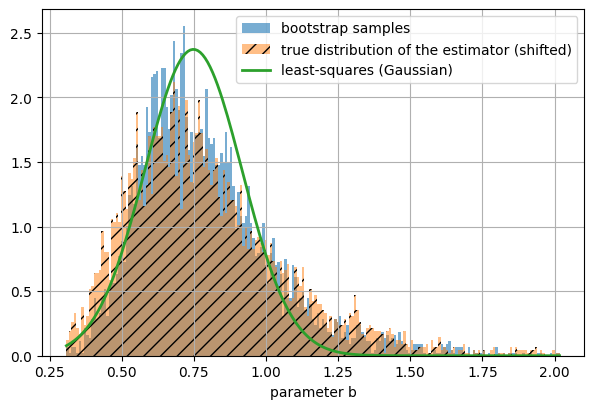

In [8]:
def exp_model(x, a, b):
    return a * np.exp(-x / (5 * b))

y_sim, y_unc = rng.normal(exp_model(x_data, a_true, b_true), 1.0), np.ones(n_points)
p0 = [a_true * 1.01, b_true * 1.01]                 # start close to the truth for a stable fit
popt, pcov = curve_fit(exp_model, x_data, y_sim, sigma=y_unc, absolute_sigma=True, p0=p0)
theta_boot = bootstrap_fit(exp_model, x_data, y_sim, y_unc, p0=popt)

lo, med, hi = np.percentile(theta_boot[:, 1], [15.9, 50, 84.1])
print(f"least squares: b = {popt[1]:.2f} +/- {np.sqrt(pcov[1,1]):.2f}")
print(f"bootstrap    : b = {med:.2f} -{med-lo:.2f} +{hi-med:.2f}")

# Who is right? In the simulation we can cheat and look at the true distribution of the estimator
b_mc = np.zeros(len(theta_boot))
for i in range(len(b_mc)):
    y_new = rng.normal(exp_model(x_data, a_true, b_true), 1.0)
    b_mc[i] = curve_fit(exp_model, x_data, y_new, sigma=y_unc, p0=p0)[0][1]

fig, ax = plt.subplots()
bb = np.linspace(*np.percentile(theta_boot[:, 1], [0.1, 99.5]), 200)
ax.hist(theta_boot[:, 1], bins=bb, density=True, alpha=0.6, label="bootstrap samples")
ax.hist(b_mc - np.median(b_mc) + np.median(theta_boot[:, 1]), bins=bb, density=True, alpha=0.5,
        hatch="//", label="true distribution of the estimator (shifted)")
ax.plot(bb, stats.norm.pdf(bb, popt[1], np.sqrt(pcov[1, 1])), lw=2, label="least-squares (Gaussian)")
ax.set_xlabel("parameter b"); ax.legend();

The true distribution of the estimator is skewed: the data constrain $b$ much better on the low side than on the high side (a long decay time is hard to distinguish from a very long one once the signal has dropped into the noise). The bootstrap reproduces this asymmetry, including the long tail towards large $b$, while the symmetric Gaussian from least squares cannot: here it underestimates the uncertainty towards high $b$. Depending on the model, least squares can under- or over-predict the uncertainty, and you do not know which unless you check.

## 2.4 Summary: three ways to an uncertainty

| method | what it needs | when it works | when it fails |
|---|---|---|---|
| least-squares covariance (`absolute_sigma=True`) | known Gaussian $\sigma_{y,i}$ | linear models, or $N$ large | non-linear models, wrong or unknown uncertainties |
| $\chi^2$ rescaling (`absolute_sigma=False`) | nothing | $N \gg k$ | small $N$ (interval is essentially random) |
| non-parametric bootstrap | a representative sample | non-linear models, non-Gaussian scatter, no uncertainties | very small $N$, strongly correlated data |
| Bayesian posterior (Chapters 4–6) | a likelihood and priors | always, and it can include the unknown scatter as a parameter | when you cannot write down a generative model |

## 2.5 Test yourself

````{admonition} Q1. The weather company (STAN exam 2023)
:class: tip
The KNMI employs scientists, who are interested in *explaining* the weather, and forecasters, who are interested in *predicting* the weather for the next few days. A new update of the weather model adds 20 parameters. After applying the updated model to data, the BIC increases by 0.5 points while the AIC decreases by 0.3 points. The scientists vote against the update, the forecasters vote in favour. Explain both points of view.

```{admonition} Answer
:class: dropdown
The forecasters care about predicting new data; a lower AIC means the updated model is (slightly) better at that, so they vote in favour. The scientists want to understand the weather with the simplest adequate model; the BIC, with its stronger penalty for parameters, says that the 20 extra parameters are not justified by the improvement in likelihood, so they vote against.
```
````

````{admonition} Q2. Bootstrap or not?
:class: tip
You fit a model with `curve_fit` and also run a bootstrap. In which of the following cases do you expect the two confidence intervals to differ, and why? (a) A straight line, 500 points, reliable Gaussian uncertainties. (b) A straight line, 6 points, no uncertainties. (c) An exponential decay fitted to 50 points with reliable uncertainties, where the decay time is poorly constrained.

```{admonition} Answer
:class: dropdown
(a) They agree: the least-squares covariance is exact for a linear model with known Gaussian uncertainties, and the bootstrap converges to the same distribution for large $N$. (b) They differ, and neither is very reliable: `curve_fit` must rescale by $\chi^2/\mathrm{dof}$ with only 4 degrees of freedom, and a bootstrap with 6 points has only 462 distinct resamples, most of which leave out a third of the data. (c) They differ: the true distribution of the decay time is asymmetric (Worked example 2), the bootstrap captures this, and the Gaussian from the linearized covariance does not.
```
````

## Sources and further reading

* Hogg, Bovy & Lang (2010), Section 4 (uncertainties on best-fit parameters; bootstrap and jackknife).
* Wasserman (2004), *All of Statistics*, Chapter 8 (bootstrap) and Section 13.6 (model selection).
* Efron & Tibshirani (1993), *An Introduction to the Bootstrap*.
* Kass & Raftery (1995), *Bayes factors*, JASA 90, 773, for the interpretation of BIC differences.
* Gelman et al., *Bayesian Data Analysis*, Section 7.4 for the Bayesian view on information criteria.